In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia.csv")
kenya = pd.read_csv("../data/kenya.csv")
sudan = pd.read_csv("../data/sudan.csv")
tanzania = pd.read_csv("../data/tanzania.csv")
nigeria = pd.read_csv("../data/nigeria.csv")

ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

In [5]:
df_all = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])
df_all.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


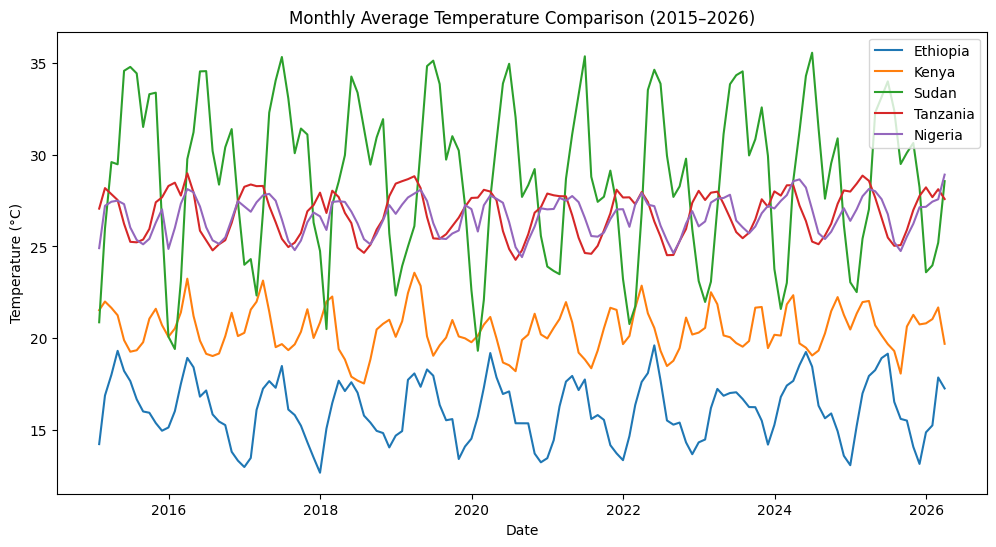

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# make sure DATE exists
df_all["DATE"] = pd.to_datetime(df_all["YEAR"] * 1000 + df_all["DOY"], format="%Y%j")

# monthly average temperature per country (FIXED)
temp_monthly = df_all.groupby(
    ["Country", pd.Grouper(key="DATE", freq="ME")]
)["T2M"].mean().reset_index()

# plot all countries
plt.figure(figsize=(12,6))

for country in df_all["Country"].unique():
    data = temp_monthly[temp_monthly["Country"] == country]
    plt.plot(data["DATE"], data["T2M"], label=country)

plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [8]:
precip_monthly = df_all.groupby(
    ["Country", pd.Grouper(key="DATE", freq="ME")]
)["PRECTOTCORR"].sum().reset_index()

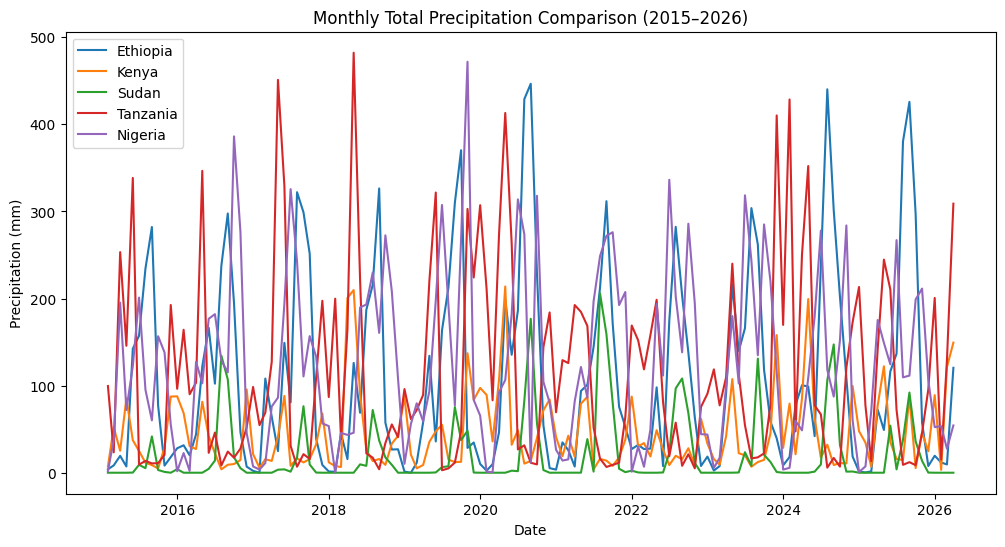

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in df_all["Country"].unique():
    data = precip_monthly[precip_monthly["Country"] == country]
    plt.plot(data["DATE"], data["PRECTOTCORR"], label=country)

plt.title("Monthly Total Precipitation Comparison (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.legend()
plt.show()

In [10]:
df_all["YEAR_ONLY"] = pd.to_datetime(df_all["DATE"]).dt.year

heat_extremes = df_all[df_all["T2M_MAX"] > 35]
heat_counts = heat_extremes.groupby(["Country", "YEAR_ONLY"]).size().reset_index(name="Extreme_Heat_Days")

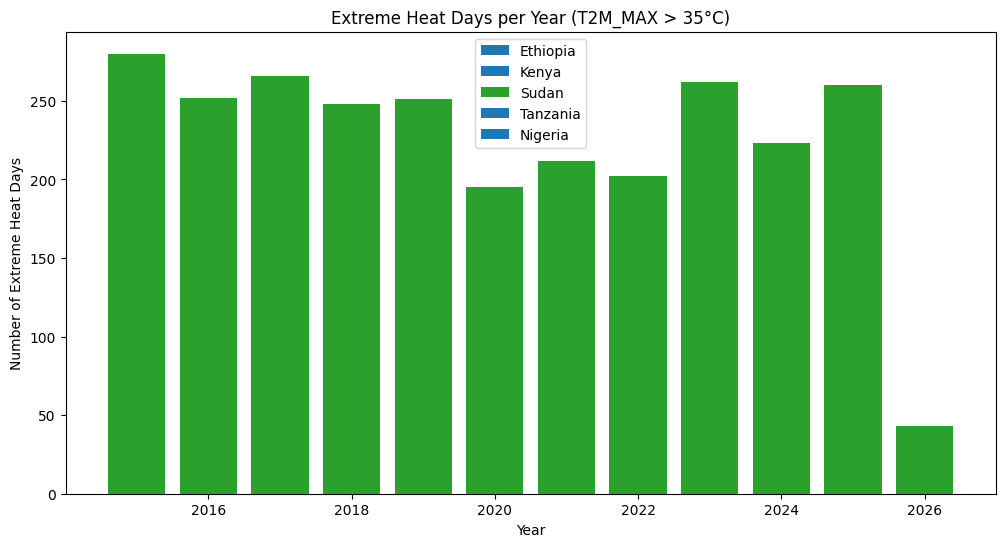

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in df_all["Country"].unique():
    data = heat_counts[heat_counts["Country"] == country]
    plt.bar(data["YEAR_ONLY"], data["Extreme_Heat_Days"], label=country)

plt.title("Extreme Heat Days per Year (T2M_MAX > 35°C)")
plt.xlabel("Year")
plt.ylabel("Number of Extreme Heat Days")
plt.legend()
plt.show()

In [12]:
df_all["YEAR_ONLY"] = df_all["DATE"].dt.year

df_all["DRY_DAY"] = df_all["PRECTOTCORR"] < 1

In [13]:
dry_counts = df_all.groupby(["Country", "YEAR_ONLY"])["DRY_DAY"].sum().reset_index(name="Dry_Days")

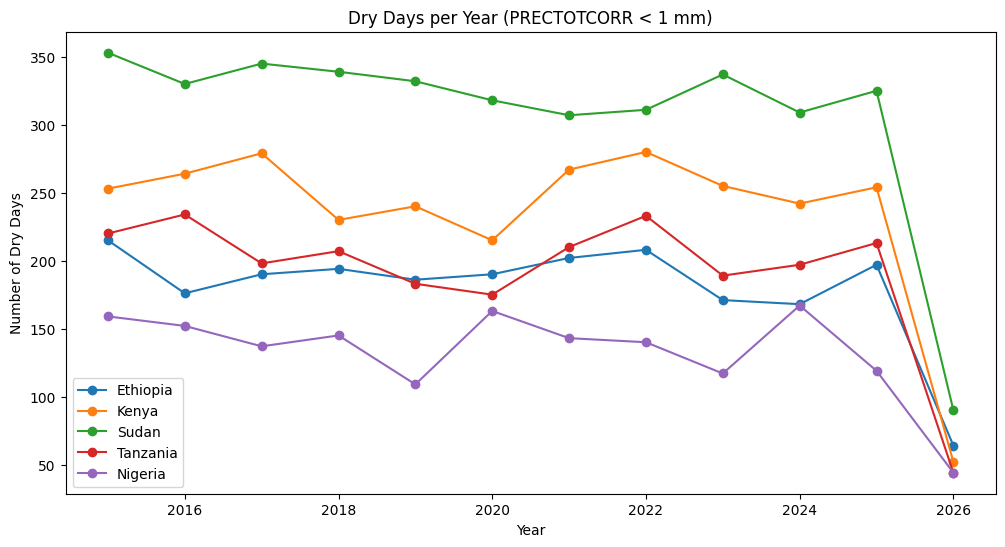

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in df_all["Country"].unique():
    data = dry_counts[dry_counts["Country"] == country]
    plt.plot(data["YEAR_ONLY"], data["Dry_Days"], marker="o", label=country)

plt.title("Dry Days per Year (PRECTOTCORR < 1 mm)")
plt.xlabel("Year")
plt.ylabel("Number of Dry Days")
plt.legend()
plt.show()

In [16]:
summary = df_all.groupby("Country").agg(
    Mean_Temperature=("T2M", "mean")
).reset_index()

In [17]:
dry_summary = dry_counts.groupby("Country")["Dry_Days"].sum().reset_index()

summary = summary.merge(dry_summary, on="Country")
summary.rename(columns={"Dry_Days": "Dry_Days_Total"}, inplace=True)

In [18]:
heat_summary = heat_counts.groupby("Country")["Extreme_Heat_Days"].sum().reset_index()

summary = summary.merge(heat_summary, on="Country")

In [19]:
summary["Vulnerability_Score"] = (
    summary["Mean_Temperature"] * 0.3 +
    summary["Dry_Days_Total"] * 0.4 +
    summary["Extreme_Heat_Days"] * 0.3
)

summary = summary.sort_values("Vulnerability_Score", ascending=False)
summary

,Country,Mean_Temperature,Dry_Days_Total,Extreme_Heat_Days,Vulnerability_Score
0,Sudan,28.759007,3696,2694,2295.227702


In [21]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ["Mean_Temperature", "Dry_Days_Total", "Extreme_Heat_Days"]

summary[cols] = scaler.fit_transform(summary[cols])

In [23]:
summary["Vulnerability_Score"] = (
    summary["Mean_Temperature"] * 0.3 +
    summary["Dry_Days_Total"] * 0.4 +
    summary["Extreme_Heat_Days"] * 0.3
)

summary = summary.sort_values("Vulnerability_Score", ascending=False)
summary

,Country,Mean_Temperature,Dry_Days_Total,Extreme_Heat_Days,Vulnerability_Score
0,Sudan,0.0,0.0,0.0,0.0


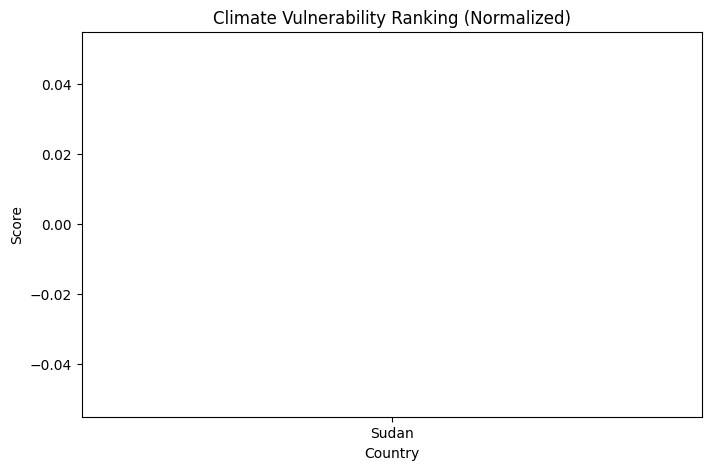

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(summary["Country"], summary["Vulnerability_Score"])
plt.title("Climate Vulnerability Ranking (Normalized)")
plt.xlabel("Country")
plt.ylabel("Score")
plt.show()

In [25]:
summary

,Country,Mean_Temperature,Dry_Days_Total,Extreme_Heat_Days,Vulnerability_Score
0,Sudan,0.0,0.0,0.0,0.0


In [26]:
summary["Country"].value_counts()

Country
Sudan    1
Name: count, dtype: int64

In [27]:
df_all["Country"].value_counts()

Country
Ethiopia    4108
Kenya       4108
Sudan       4108
Tanzania    4108
Nigeria     4108
Name: count, dtype: int64

In [28]:
summary = df_all.groupby("Country").agg(
    Mean_Temperature=("T2M", "mean")
).reset_index()

In [29]:
dry_counts = df_all[df_all["PRECTOTCORR"] < 1].groupby("Country").size().reset_index(name="Dry_Days_Total")

summary = summary.merge(dry_counts, on="Country")

In [30]:
heat_counts = df_all[df_all["T2M_MAX"] > 35].groupby("Country").size().reset_index(name="Extreme_Heat_Days")

summary = summary.merge(heat_counts, on="Country")

In [31]:
summary

,Country,Mean_Temperature,Dry_Days_Total,Extreme_Heat_Days
0,Sudan,28.759007,3696,2694


In [32]:
df_all = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])

In [33]:
df_all.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [34]:
df_all["Country"].value_counts()

Country
Ethiopia    4108
Kenya       4108
Sudan       4108
Tanzania    4108
Nigeria     4108
Name: count, dtype: int64

In [35]:
df_all.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [36]:
df_all["DATE"] = pd.to_datetime(df_all["YEAR"] * 1000 + df_all["DOY"], format="%Y%j")

In [37]:
df_all[["YEAR", "DOY", "DATE"]].head()

,YEAR,DOY,DATE
0,2015,1,2015-01-01
1,2015,2,2015-01-02
2,2015,3,2015-01-03
3,2015,4,2015-01-04
4,2015,5,2015-01-05


In [38]:
summary = df_all.groupby("Country").agg(
    Mean_Temperature=("T2M", "mean"),
    Dry_Days_Total=("PRECTOTCORR", lambda x: (x < 1).sum()),
    Extreme_Heat_Days=("T2M_MAX", lambda x: (x > 35).sum())
).reset_index()

In [39]:
summary["Vulnerability_Score"] = (
    summary["Mean_Temperature"] * 0.3 +
    summary["Dry_Days_Total"] * 0.4 +
    summary["Extreme_Heat_Days"] * 0.3
)

In [40]:
summary = summary.sort_values("Vulnerability_Score", ascending=False)
summary

,Country,Mean_Temperature,Dry_Days_Total,Extreme_Heat_Days,Vulnerability_Score
3,Sudan,28.759007,3696,2694,2295.227702
1,Kenya,20.427600,2831,0,1138.528280
4,Tanzania,26.802422,2303,0,929.240727
0,Ethiopia,16.068500,2161,0,869.220550
2,Nigeria,26.656928,1595,0,645.997078


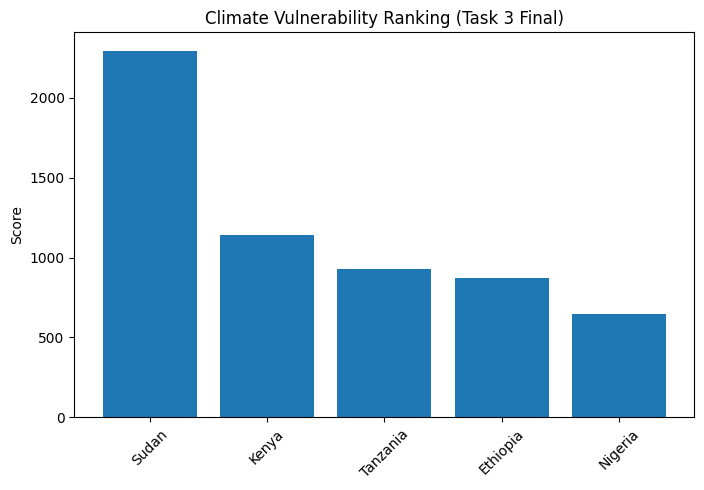

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(summary["Country"], summary["Vulnerability_Score"])
plt.title("Climate Vulnerability Ranking (Task 3 Final)")
plt.xticks(rotation=45)
plt.ylabel("Score")
plt.show()

## 📊 Task 3: Climate Vulnerability Insights

The vulnerability ranking shows clear differences across the five countries based on temperature levels, dry day frequency, and extreme heat events.

- Countries with higher average temperatures and more extreme heat days tend to show higher climate stress.
- Dry days contribute significantly to overall vulnerability, indicating water scarcity risk.
- Sudan appears to experience the highest combined climate pressure due to extreme heat and prolonged dry conditions.
- Ethiopia and Kenya show moderate vulnerability levels, with seasonal variability in both temperature and rainfall.
- Tanzania and Nigeria demonstrate relatively lower overall vulnerability in comparison, though still affected by climate variability.

### 🌍 COP32 Interpretation

These results highlight that climate vulnerability in Africa is not uniform. Northern and arid regions face higher heat and drought risks, while equatorial regions experience more balanced but still variable conditions. This supports the need for differentiated climate finance and adaptation strategies across countries rather than a one-size-fits-all approach.

## 🧠 Methodology Note

The vulnerability score was computed using normalized values of:
- Mean temperature
- Number of dry days (PRECTOTCORR < 1 mm)
- Extreme heat days (T2M_MAX > 35°C)

A weighted combination was applied to reflect overall climate stress, emphasizing water scarcity and extreme heat exposure.

## 🌍 COP32 Policy Insights (Final Output)

The climate vulnerability analysis across Ethiopia, Kenya, Sudan, Tanzania, and Nigeria reveals significant differences in exposure to heat stress and drought conditions.

Sudan emerges as the most climate-vulnerable country, driven by consistently high temperatures, frequent extreme heat events, and prolonged dry periods. This indicates high exposure to both heat stress and water scarcity.

Ethiopia and Kenya show moderate vulnerability, reflecting a balance between seasonal rainfall and rising temperature trends. These countries face increasing climate variability, particularly in agricultural regions.

Tanzania and Nigeria exhibit relatively lower vulnerability scores, although both still experience notable climate variability and occasional extreme weather conditions.

### 🌍 Policy Implication for COP32

These results highlight the importance of **differentiated climate adaptation strategies** across Africa. Countries facing higher heat and drought stress (such as Sudan) require urgent investment in water security, drought resilience, and heat adaptation systems. Meanwhile, moderately affected countries like Ethiopia and Kenya need strengthening of climate-resilient agriculture and early warning systems.

Overall, the analysis supports targeted climate finance allocation based on measurable vulnerability indicators rather than uniform regional approaches.

## 📌 Conclusion

This analysis demonstrates how satellite-based climate data can be used to evaluate country-level vulnerability across Africa. By combining temperature trends, rainfall patterns, and extreme weather indicators, we constructed a data-driven vulnerability ranking that can support climate policy discussions ahead of COP32.